# Hierarchical Gaussian fit (numpyro)

Here I demonstrate how to fit a Gaussian hierarchically using _numpyro_ and CPUs. We use a KDE to smoothen over samples.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import arviz as az
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
numpyro.set_host_device_count(8)

In [3]:
jax.local_device_count()

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


8

In [4]:
def make_model(x_samples_stack, manual=False):
    Nobs = x_samples_stack.shape[0]
    Nsamp = x_samples_stack.shape[1]

    # hyper prior
    mu = numpyro.sample('mu', dist.Uniform(-1, 1))
    sigma = numpyro.sample('sigma', dist.Uniform(0, 1))

    # compute KDE bandwidths using Scott's rule
    bws = np.std(x_samples_stack, axis=1)/Nsamp**(1.0/5.0)

    sigma_tot = jnp.sqrt(jnp.square(sigma) + bws**2)

    def log_density(xs, m, s):
        return dist.Normal(m, s).log_prob(xs)

    logps = log_density(x_samples_stack.T, mu, sigma_tot)
    evt_log_mean_wts = jax.nn.logsumexp(logps, axis=0) - np.log(Nsamp)
    numpyro.factor('log_likelihood', jnp.sum(evt_log_mean_wts))

In [5]:
# test model: simulate some events

mu_true = 0.
sigma_true = 0.

Nobs = 100
Nsamp = 1000

sigma_obs = 0.1

fake_truths = np.random.normal(mu_true, sigma_true, Nobs)
fake_obs = np.random.normal(0, sigma_obs, (Nobs, Nsamp)) + fake_truths[:,np.newaxis]

In [6]:
nmcmc = 1000
nchain = 4

kernel = NUTS(make_model)
mcmc = MCMC(kernel, num_warmup=nmcmc, num_samples=nmcmc, num_chains=nchain)
mcmc.run(jax.random.PRNGKey(1234), fake_obs)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [7]:
result = az.from_numpyro(mcmc)

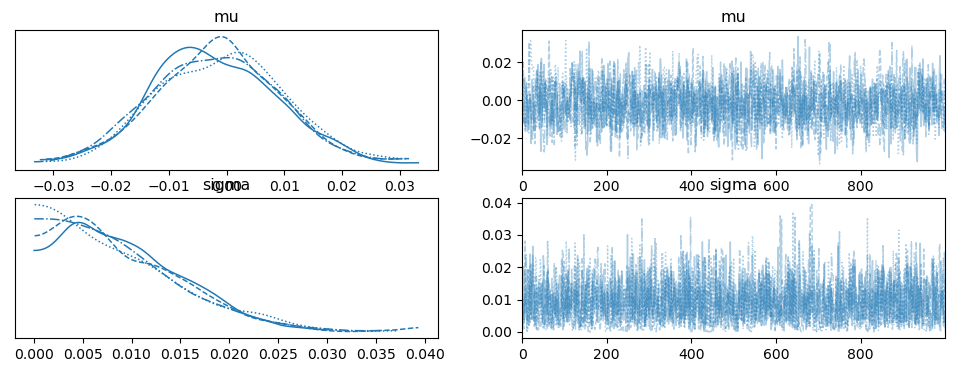

In [8]:
az.plot_trace(result, var_names=['mu', 'sigma']);